# Regression Modeling with Argo Data

## Overview

This workbook goes through the main steps for training a machine learning regression model using Argo data. 

The main functions live in a separate file `argotools.py`, which we import as the module `mod_argo` (recommend opening `argotools.py` in another window to follow along). The benefit of this modular approach is that you can access useful functions across different notebooks and avoid copy/pasting large sections of code. (If you create several modules you need to reuse for many projects, you can also reformat these into an [Python package](https://packaging.python.org/en/latest/tutorials/packaging-projects/) to install within your conda environment.)



In [2]:
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

import matplotlib.pyplot as plt
from cmocean import cm as cmo
from cartopy import crs as ccrs

from scipy.stats import iqr
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Custom module
import argotools as mod_argo

# 0. (Optional) Argopy Data import



The Argo data in this notebook can be downloaded using the Python package [Argopy](https://argopy.readthedocs.io/en/latest/). Argopy offers many utilities which are not covered here, with several example notebooks at on their website. 

To use data that has already been downloaded, skip to Section 1. 

In [ ]:
from argopy import DataFetcher 
# from argopy import ArgoIndex  

import argopy
argopy.reset_options()
argopy.clear_cache()
argopy.set_options(cachedir='cache_bgc')
argopy.set_options(src='erddap') # Ifremer database, updated daily

# Set to False to avoid JupyterHub crashing with multiple users.
rerun_Argopy = False
rerun_save = False

In [ ]:
# Query data around the mooring
if rerun_Argopy:
      # Format: [lon_min, lon_max, lat_min, lat_max, pres_min, pres_max, datim_min, datim_max]
      BOX = [-140, -100, 15, 55, 0, 1000, '2020-01-01', '2026-12-31']

      # Construct fetchers for bgc floats first
      # Expert mode returns all QC flags
      # Updated Feb 4 2025, use local copy of GDAC (Snapshot 01-09)
      fetcher = DataFetcher(ds='bgc', mode='expert', params='all',
                        measured=['NITRATE', 'DOXY'],
                  parallel=True, progress=True,
                  chunks_maxsize={'time': 30},
                  )
      bgc_fetcher = fetcher.region(BOX).load()

      # Returns xr Dataset with point observations as dimension
      bgc_profiles = bgc_fetcher.data.argo.point2profile();
      bgc_profiles = bgc_profiles.assign_attrs(raw_attrs = '', Fetched_uri='') # simplify for save

      # Store index and domain
      bgc_index = bgc_fetcher.index
      bgc_domain = bgc_fetcher.domain 

Final post-processing of the merged dataset ...


In [ ]:
if rerun_Argopy:
    cceDF = mod_argo.create_argo_dataframe(bgc_profiles, 
                                                bgc_list = ['nitrate', 'oxygen'])

    qc_cols = ['temperature_qc', 'salinity_qc', 'pressure_qc', 'time_qc', 'position_qc', 'nitrate_qc', 'oxygen_qc'] 
    cceDF_QC = mod_argo.filter_qc_flags(cceDF, qc_vars=qc_cols, use_flags=['1', '2', '5', '8'])
    cceDF_QC = mod_argo.expand_datetime(cceDF_QC)
    cceDF_QC = mod_argo.add_mlp(cceDF_QC, threshold=0.03)

if rerun_save:
    datetag = datetime.now().strftime("%Y%m%d")
    cceDF_QC.to_csv('../data/argopy_qc1258_acc' + datetag + '.csv')


Using flags:  ['1', '2', '5', '8']
# of profiles before QC filtering: 	 4849
# of obs before QC filtering: 		 378222 

                     1     2  5       8 nobs_dropped nobs_remaining
temperature_qc   60086     0  0  172007       146129         232093
salinity_qc      57521  2442  0  170831         1299         230794
pressure_qc     230794     0  0       0            0         230794
time_qc         230794     0  0       0            0         230794
position_qc     223595     0  0    7199            0         230794
nitrate_qc      203452  4184  0    1082        22076         208718
oxygen_qc       207700     0  0     924           94         208624

# of profiles after QC filtering: 	 3763



3763


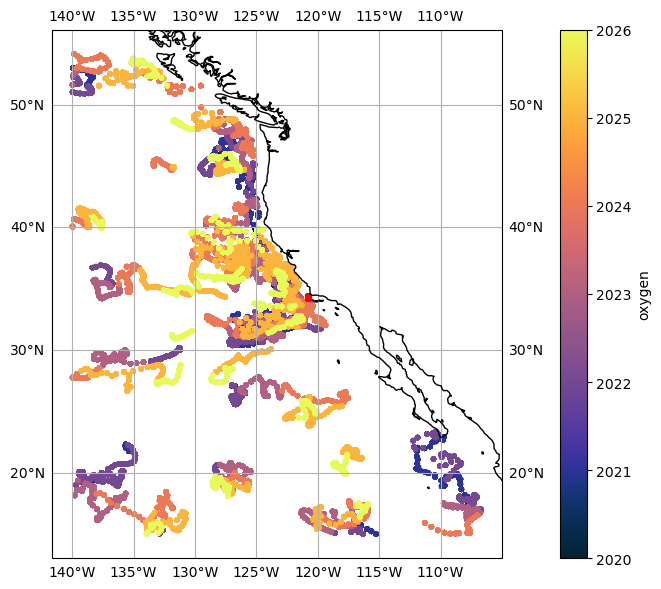

In [291]:
# Initial look at the data
plot_data = cceDF_QC.copy()
print(len(plot_data.profid.unique()))
# print(len(plot_data))

fig = plt.figure(figsize=(12, 6), layout='tight')
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
sca = ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.year, s=8, transform=ccrs.PlateCarree(), label='bgc Argo', 
           cmap=cmo.thermal)
ax.coastlines(resolution = "50m", zorder=5, linewidth = 1)
ax.scatter((-120.803990+360), 34.303747, c='r', s=20, marker='s', transform=ccrs.PlateCarree())
plt.colorbar(sca, label = 'oxygen')
# ax.set_xlim([20,50])
ax.set_aspect('equal')
ax.gridlines(draw_labels=True)


# 1. Splitting training/validation data (fold subsetting)

In [171]:
# If skipping Argopy section, load the previously saved CSV file
cceDF_QC = pd.read_csv('../argopy_qc1258_acc20260803.csv', index_col=0)
cceDF_QC.head()

,wmoid,profid,latitude,longitude,datetime,pressure,CT,SA,sigma0,spice,...,nitrate_qc,nitrate_error,oxygen,oxygen_qc,oxygen_error,year,month,day,mlp,mld
3276,5906293,5906293_cyc001,45.486,-127.398,2020-08-13 03:17:45.000000000,7.60,17.984167,32.216022,23.052335,0.791638,...,1,1.229948,247.77210,1,2.299476,2020,8,13,26.544309,26.326001
3277,5906293,5906293_cyc001,45.486,-127.398,2020-08-13 03:17:45.000000000,11.58,17.968156,32.219359,23.058692,0.790242,...,1,1.230007,247.92221,1,2.300064,2020,8,13,26.544309,26.326001
3278,5906293,5906293_cyc001,45.486,-127.398,2020-08-13 03:17:45.000000000,16.83,17.938163,32.219355,23.065876,0.782967,...,1,1.230120,248.34480,1,2.301204,2020,8,13,26.544309,26.326001
3279,5906293,5906293_cyc001,45.486,-127.398,2020-08-13 03:17:45.000000000,21.51,17.919521,32.219389,23.070364,0.778477,...,1,1.230174,248.92813,1,2.301737,2020,8,13,26.544309,26.326001
3280,5906293,5906293_cyc001,45.486,-127.398,2020-08-13 03:17:45.000000000,26.58,17.850880,32.222475,23.089099,0.764171,...,1,1.230451,250.69673,1,2.304511,2020,8,13,26.544309,26.326001


To develop the model, we first need to separate the training and validation data. (Independent test data should also be reserved to give an estimate of error for the final model selection.)


Scikit-learn has many built-in functionalities for splitting data ([visual examples](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py)) that you can explore in [more detail](https://scikit-learn.org/stable/api/sklearn.model_selection.html#splitters).

Here, we use a custom class called `CrossValContainer` to keep track of our training and validation data for each fold. 
We use the sklearn implementation of `KFold` as the simplest random splitter, then introduce two other forms of splitting that are recommended over simple shuffling: 

1. by platform: shuffle the data by float WMO, keeping profiles from the same float together during subsetting
2. by [k-means clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html): group the data using spatial coordinates, with optional zonal/meridional weighting


All three forms of splitting are called using the custom function `subset_folds()`, which helps organize the different types of shuffling into a consistent format. Other splitters (e.g. Leave-One-Out or GroupKFold) can easily be added to the function.  

In [ ]:
# Choose spatial bounds and pressure limits 
pres_lims = [50, 150]
longitude_lims = [-125, -115]
latitude_lims = [30, 40]

input_data = cceDF_QC[(cceDF_QC.pressure > pres_lims[0]) & (cceDF_QC.pressure < pres_lims[1]) &
                     (cceDF_QC.longitude > longitude_lims[0]) & (cceDF_QC.longitude < longitude_lims[1]) & 
                     (cceDF_QC.latitude > latitude_lims[0]) & (cceDF_QC.latitude < latitude_lims[1]) &
                     (cceDF_QC.year >2020)].reset_index().drop(['index'], axis=1)

# Add time features
input_data['datetime'] = input_data['datetime'].astype('datetime64[ns]')
input_data['linear_time'] = mod_argo.datetime2linear(input_data['datetime'], ref_time = '2020-01-01')
input_data['ydcos'], input_data['ydsin'] = mod_argo.add_seasonal_sines(input_data['linear_time'])
input_data.head()

# input_data

,wmoid,profid,latitude,longitude,datetime,pressure,CT,SA,sigma0,spice,...,oxygen_qc,oxygen_error,year,month,day,mlp,mld,linear_time,ydcos,ydsin
0,5906295,5906295_cyc006,31.837,-122.702,2021-01-01 10:51:58.000999936,52.059998,14.014474,33.323914,24.779063,0.706386,...,1,2.451829,2021,1,1,62.954772,62.507526,366.452755,0.999786,0.020689
1,5906295,5906295_cyc006,31.837,-122.702,2021-01-01 10:51:58.000999936,57.059998,14.011102,33.323962,24.779795,0.705702,...,1,2.451550,2021,1,1,62.954772,62.507526,366.452755,0.999786,0.020689
2,5906295,5906295_cyc006,31.837,-122.702,2021-01-01 10:51:58.000999936,62.010000,13.974293,33.322151,24.785989,0.696521,...,1,2.452853,2021,1,1,62.954772,62.507526,366.452755,0.999786,0.020689
3,5906295,5906295_cyc006,31.837,-122.702,2021-01-01 10:51:58.000999936,67.100006,13.185841,33.269990,24.905258,0.492926,...,1,2.486203,2021,1,1,62.954772,62.507526,366.452755,0.999786,0.020689
4,5906295,5906295_cyc006,31.837,-122.702,2021-01-01 10:51:58.000999936,71.960000,12.403904,33.250390,25.042080,0.320147,...,1,2.528029,2021,1,1,62.954772,62.507526,366.452755,0.999786,0.020689


In [186]:
# Split data into folds (shuffle by WMO)
nfolds = 5
cvtainer_bySample = mod_argo.CrossValContainer(input_data, nfolds)
cvtainer_byPlatform = mod_argo.CrossValContainer(input_data, nfolds)
cvtainer_byKmeans = mod_argo.CrossValContainer(input_data, nfolds)

# shuffled randomly by sample
[cvtainer_bySample.training_inds, 
 cvtainer_bySample.validation_inds] = mod_argo.subset_folds(input_data, type='random',
                                                            nfolds=nfolds)

# by platform  (indexer='wmoid') or by profile (indexer='profid')
[cvtainer_byPlatform.training_inds, 
 cvtainer_byPlatform.validation_inds] = mod_argo.subset_folds(input_data, type='platform',
                                                              indexer='wmoid', nfolds=nfolds)

# by k-means clustering
[cvtainer_byKmeans.training_inds, 
 cvtainer_byKmeans.validation_inds] = mod_argo.subset_folds(input_data, type='kmeans',
                                                            nfolds=nfolds, latitude_scaler = 1)

fold_tags = ['fold' + str(k) for k in range(1, nfolds+1)] # Number of folds

## 1.1 Maps

829


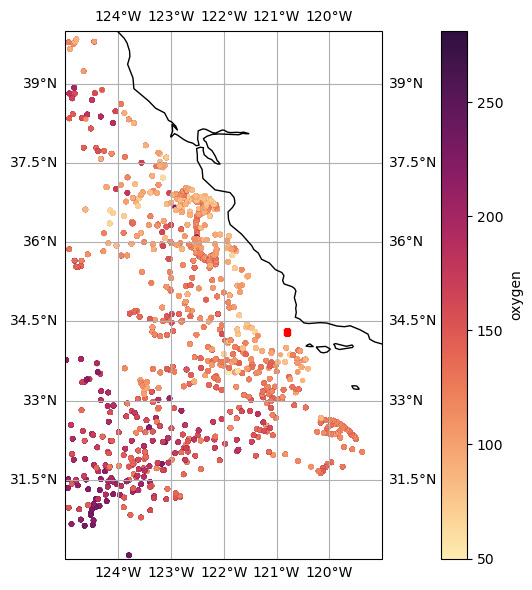

In [175]:
plot_data = input_data.copy()
print(len(plot_data.profid.unique()))
# print(len(plot_data))

fig = plt.figure(figsize=(12, 6), layout='tight')
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
sca = ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.oxygen, s=8, transform=ccrs.PlateCarree(), label='bgc Argo', 
        #    vmin=0, vmax=25,
           cmap=cmo.matter)


ax.scatter((-120.803990+360), 34.303747, c='r', s=20, marker='s', transform=ccrs.PlateCarree())
plt.colorbar(sca, label = 'oxygen')
# ax.set_xlim([20,50])
# ax.set_extent([longitude_lims[0]-1, -119, latitude_lims[0]-1, latitude_lims[1]+1], crs=ccrs.PlateCarree())
ax.set_extent([-125, -119, 30, 40])
ax.coastlines(resolution = "50m", zorder=5, linewidth = 1)
ax.set_aspect('equal')
ax.gridlines(draw_labels=True)


The `CrossValContainer` class also has a function for quickly visualizing the training and validation splits called `.map_folds()`. Storing the plotting function in our module is a nice way to reuse plot code.

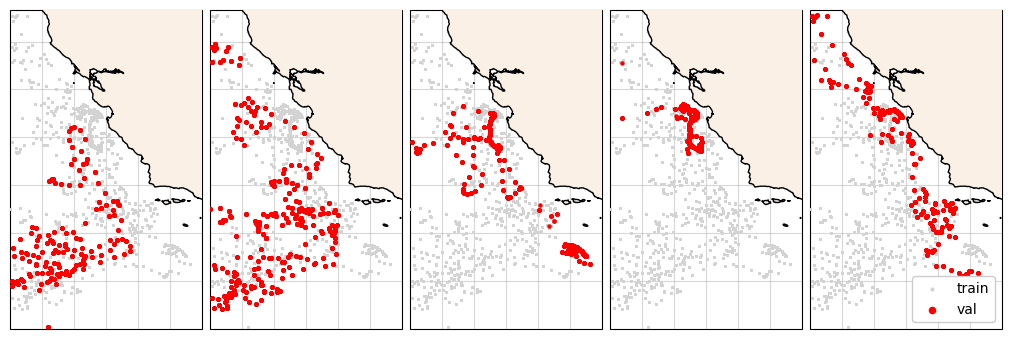

In [176]:
fig, axs = cvtainer_byPlatform.map_folds(ax_lims = [-125, -119, 30, 40])

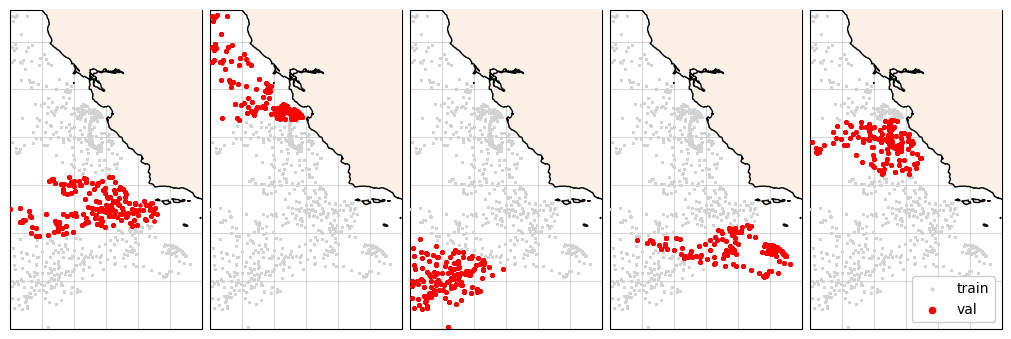

In [177]:
fig, axs = cvtainer_byKmeans.map_folds(ax_lims = [-125, -119, 30, 40])

# 2. Model training


In this section, we look at two aspects of regression modeling: 
1. Feature lists: what input variables does the model consider for estimating the target variable?
2. Hyperparameters: what algorithm architecture leads to the best performance?

We'll use the object `CrossValModelRun` to store results by fold for each model. 

## 2.1 Example: Comparing feature lists with K-fold CV

We can run multiple versions of the model to explore the performance of various feature lists and how results may change depending on the cross-validation setup. 

In [ ]:
# Set feature lists to iterate over 
feat_lists = [['CT', 'SA', 'oxygen', 'pressure', 'mld'],
              ['CT', 'SA', 'oxygen', 'pressure', 'mld', 'latitude', 'longitude'], # add space
              ['CT', 'SA', 'oxygen', 'pressure', 'mld', 'latitude', 'longitude', 'linear_time'], # add space/time
              ['CT', 'SA', 'oxygen', 'pressure', 'mld', 'latitude', 'longitude', 'ydcos', 'ydsin']] # add space/season

# Set run parameters and create "run tags" for the model iterations
use_algorithm = 'RFR'
target_variable = 'nitrate'

# use_cvtainer = cvtainer_byPlatform
use_hyperparams = {'max_features': 2, # see Section 2.2
                    'min_samples_split': 10,
                    'n_estimators': 1000}
feat_options, feat_tags = mod_argo.label_run_options(feat_lists) # Converts list to dictionary

# Initialize storage dictionary
# WARNING: Comment out below if running partial:
storedRuns_bySample = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}
storedRuns_byPlatform = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}
storedRuns_byKmeans = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}


In [190]:
# Iteratively train models and store results in a CrossValModelRun object for each feat_tags
for runkey in feat_tags[:]:
    storedRuns_bySample[runkey] = mod_argo.fit_cv_model(cvtainer_bySample, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)
    
    storedRuns_byPlatform[runkey] = mod_argo.fit_cv_model(cvtainer_byPlatform, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)
    
    storedRuns_byKmeans[runkey] = mod_argo.fit_cv_model(cvtainer_byKmeans, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)


In [ ]:
storedRuns_bySample['featA'].collapse_errors() # single dataframe

,wmoid,profid,latitude,longitude,datetime,pressure,CT,SA,sigma0,spice,...,linear_time,ydcos,ydsin,sin_longitude,cos_longitude,scaled_latitude,fold,val_prediction,val_error,val_relative_error
8,5906295,5906295_cyc006,31.8370,-122.7020,2021-01-01 10:51:58.000999936,91.830000,10.808163,33.536384,25.553879,0.222525,...,366.452755,0.999786,0.020689,-0.841492,-0.540270,-0.911281,2,14.597313,0.513711,0.036476
14,5906295,5906295_cyc006,31.8370,-122.7020,2021-01-01 10:51:58.000999936,142.170000,9.618889,34.014820,26.125628,0.356314,...,366.452755,0.999786,0.020689,-0.841492,-0.540270,-0.911281,2,24.554687,0.306491,0.012640
15,5906294,5906294_cyc011,33.1680,-123.3630,2021-01-10 00:12:36.000000000,51.470000,14.126273,33.137720,24.613833,0.593107,...,375.008750,0.985942,0.167087,-0.835203,-0.549942,-0.844465,0,0.714487,-0.143786,-0.167530
19,5906294,5906294_cyc011,33.1680,-123.3630,2021-01-10 00:12:36.000000000,71.509995,12.626496,33.011840,24.816503,0.189815,...,375.008750,0.985942,0.167087,-0.835203,-0.549942,-0.844465,0,2.773372,0.441290,0.189226
27,5906294,5906294_cyc011,33.1680,-123.3630,2021-01-10 00:12:36.000000000,121.729996,10.376367,33.581960,25.663786,0.176684,...,375.008750,0.985942,0.167087,-0.835203,-0.549942,-0.844465,0,17.378661,1.955461,0.126787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14362,5906883,5906883_cyc035,34.6483,-123.7787,2026-07-28 11:00:00.000999936,55.790000,15.687284,33.408699,24.485632,1.137841,...,2400.458333,-0.899139,-0.437662,-0.831191,-0.555987,-0.770153,0,0.729352,-0.284094,-0.280325
14365,5906883,5906883_cyc035,34.6483,-123.7787,2026-07-28 11:00:00.000999936,71.790000,14.172984,33.313518,24.738345,0.732655,...,2400.458333,-0.899139,-0.437662,-0.831191,-0.555987,-0.770153,0,1.264460,-1.819232,-0.589952
14368,5906883,5906883_cyc035,34.6483,-123.7787,2026-07-28 11:00:00.000999936,85.790000,13.331007,33.374070,24.956062,0.599415,...,2400.458333,-0.899139,-0.437662,-0.831191,-0.555987,-0.770153,0,5.752893,-1.019881,-0.150585
14373,5906883,5906883_cyc035,34.6483,-123.7787,2026-07-28 11:00:00.000999936,101.790000,11.776976,33.491950,25.345273,0.373695,...,2400.458333,-0.899139,-0.437662,-0.831191,-0.555987,-0.770153,0,13.756986,-0.756133,-0.052100


In [199]:
[print(k,v) for k,v in feat_options.items()]; print()

_ = mod_argo.storedRuns_comparison(storedRuns_bySample, error_param='val_error', show = True)
_ = mod_argo.storedRuns_comparison(storedRuns_byPlatform, error_param='val_error', show = True)
# mod_argo.storedRuns_comparison(storedRuns_byKmeans, error_param='val_error', show = True)

featA ['CT', 'SA', 'oxygen', 'mld']
featB ['CT', 'SA', 'oxygen', 'mld', 'latitude', 'longitude']
featC ['CT', 'SA', 'oxygen', 'mld', 'latitude', 'longitude', 'linear_time']
featD ['CT', 'SA', 'oxygen', 'mld', 'latitude', 'longitude', 'ydcos', 'ydsin']

       median_AE   mean_AE      bias      RMSE
featA   0.438962  0.616895 -0.000583  0.860297
featB   0.336644  0.493464 -0.001291  0.703914
featC   0.294767  0.433019 -0.000157  0.623312
featD   0.302770  0.447473 -0.002400  0.640855
       median_AE   mean_AE      bias      RMSE
featA   0.593997  0.800836 -0.013387  1.105067
featB   0.647942  0.827451 -0.009352  1.116158
featC   0.614115  0.787800 -0.027145  1.055957
featD   0.647700  0.826331 -0.034189  1.110875


## 2.2 Example: Exporing hyperparameters

During cross-validation workflow, we can also tune the hyperparameters that control the machine learning architecture. This tuning is often automated using functions from sklearn (e.g. GridSearchCV, RandomSearchCV). There are also more sophisticated methods (e.g. multivariate TPE sampling) that can speed up the process when sampling a large parameter space. 


For this demo, we won't perform the full hyperparmeter tuning, but we can compare a few sets of selected hyperparameter options to show that these choices can also affect performance. 
<!-- 
Note that in the previous example, we used RFR, which can be less sensitive to parameter tuning (works well out of the box).  related algorithm from sklearn, `ExtraTreesRegressor`.  -->



In [202]:
# Set hyperparameter options to iterate over 
# These are translated into a dictionary before the fit_single_fold() call
hyperparam_tags = ['maxfeat5_minsplit10_nest100',
                    'maxfeat5_minsplit10_nest1000']
hyper_options, hyper_tags = mod_argo.label_run_options(hyperparam_tags, prefix='hyper') # Converts list to dictionary


# Set run parameters and feature lists
use_feat_list = ['CT', 'SA', 'oxygen']
use_algorithm = 'RFR'
use_cvtainer = cvtainer_byPlatform
target_variable = 'nitrate'


In [ ]:
# Comment out if you want to store previous runs:
storedRuns_hyper = {runkey:{nfold:None for nfold in use_cvtainer.fold_list} for runkey in hyper_tags}

# Use "runkeys" as an identifier for each version of the model, here by feature list:
# Iteratively train models and store results in a CrossValModelRun object for each runkey
for runkey in hyper_tags[:]:
    use_hyperparams = mod_argo.expand_hyperparam_tag(hyper_options[runkey])
    storedRuns_hyper[runkey] = mod_argo.fit_cv_model(cvtainer_byPlatform, target_variable,
                                                use_feats = use_feat_list,
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)
    

## 2.3 Linear calibration

In [ ]:
# #  Collapse folds into a single Dataframe for each run tag
# storedRuns_collapsed = {rkey: None for rkey in feat_options.keys()}
# for k,v in storedRuns_feat.items(): # or choose storedRuns_hyper
#     storedRuns_collapsed[k] = v.collapse_errors(fold_tags)

0.982795004720542


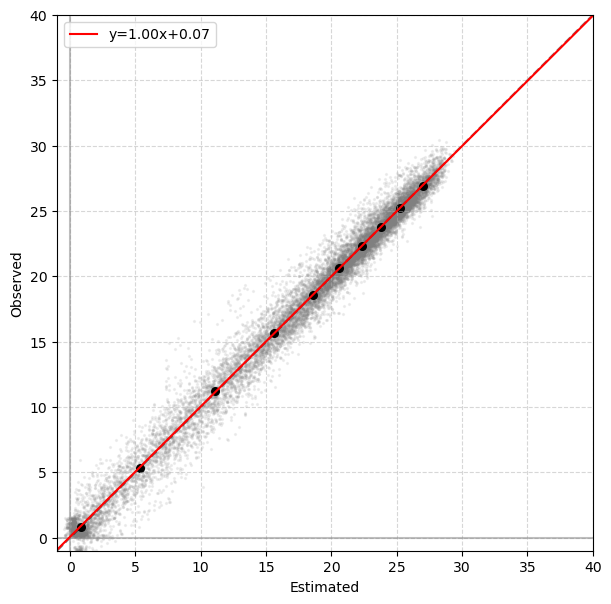

In [203]:
# Calibration plot
from sklearn.metrics import r2_score
plot_data = storedRuns_byPlatform['featA'].collapse_errors()

# === 
fig = plt.figure(figsize=(6,6), layout='constrained')
ax = fig.gca()

ax.scatter(plot_data.val_prediction, plot_data[target_variable], alpha=0.1, s=2, color='grey')
ax.set_aspect('equal')
plot_data['n_decile'] = pd.qcut(plot_data['val_prediction'].values.tolist(), 10, labels=list(range(1, 11))) #
cal_pred = plot_data.groupby('n_decile', observed=False)['val_prediction'].agg(['mean', 'min', 'max', 'count'])
cal_obs = plot_data.groupby('n_decile', observed=False)[target_variable].agg(['mean', 'min', 'max', 'count'])

mod_argo.plot_decile_calibration(ax, cal_pred, cal_obs, axlims=[-1,40])
print(r2_score(plot_data[target_variable], plot_data.val_prediction))

In [205]:
# Apply a linear calibration using decile means
storedRuns_calibrated = {rkey: None for rkey in storedRuns_byPlatform.keys()}
cal_coeffs = {k:None for k in storedRuns_byPlatform.keys()}
for k,v in storedRuns_byPlatform.items():
    storedRuns_calibrated[k], cal_coeffs[k] = mod_argo.apply_linear_calibration(v.collapse_errors(), target_variable)

In [213]:
storedRuns_calibrated

{'featA':          wmoid          profid  latitude  longitude  \
 0      5906295  5906295_cyc006   31.8370  -122.7020   
 1      5906295  5906295_cyc006   31.8370  -122.7020   
 2      5906295  5906295_cyc006   31.8370  -122.7020   
 3      5906295  5906295_cyc006   31.8370  -122.7020   
 4      5906295  5906295_cyc006   31.8370  -122.7020   
 ...        ...             ...       ...        ...   
 13658  5906517  5906517_cyc133   39.7976  -124.4536   
 13659  5906517  5906517_cyc133   39.7976  -124.4536   
 13660  5906517  5906517_cyc133   39.7976  -124.4536   
 13661  5906517  5906517_cyc133   39.7976  -124.4536   
 13662  5906517  5906517_cyc133   39.7976  -124.4536   
 
                            datetime    pressure         CT         SA  \
 0     2021-01-01 10:51:58.000999936   52.059998  14.014474  33.323914   
 1     2021-01-01 10:51:58.000999936   57.059998  14.011102  33.323962   
 2     2021-01-01 10:51:58.000999936   62.010000  13.974293  33.322151   
 3     2021-01-01 10:

# 3. Error analysis

In [216]:
mod_argo.storedRuns_comparison(storedRuns_calibrated, by_fold=False, error_param='lincal_error', show=False)


,median_AE,mean_AE,bias,RMSE
featA,0.593195,0.800537,0.000002,1.104677
featB,0.646222,0.827073,0.000007,1.113773
featC,0.622351,0.782855,0.000011,1.044683
featD,0.647408,0.818613,0.000003,1.096643


In [ ]:
# # Pangaea 2014–2024
# storedRuns_summary = mod_argo.storedRuns_comparison(storedRuns_pang_collapsed, 
#                                                     run_tags = feat_keys,
#                                                     error_param='val_error') # exclude class 4

# # Choose which type of run to show
# # show_rows = [x for x in run_tags if 'combined' in x]
# show_rows = storedRuns_summary.index.tolist()

# # Choose order
# storedRuns_summary.loc[show_rows]
# storedRuns_summary.loc[show_rows].sort_values('median_AE')

,median_AE,mean_AE,bias,RMSE
featB,1.075713,1.433973,0.374779,1.938133
featA,1.178810,1.813577,0.559360,2.616667


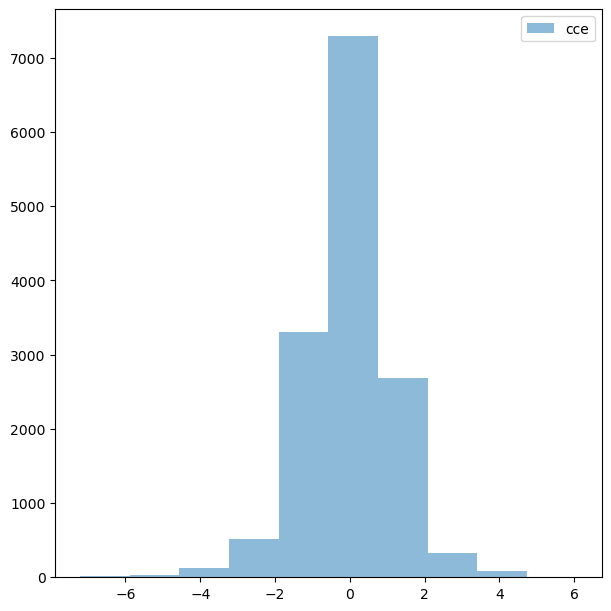

In [ ]:
fig = plt.figure(figsize=(6,6), layout='constrained')
ax = fig.gca()
ax.hist(storedRuns['featB'].val_error, bins=10, alpha=0.5, label = 'cce')
plt.legend()

In [182]:
# Add other plots here

# Application to mooring data